In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv('./processed.csv', index_col=0)
df.head()

,date,likes,content,username,media,inferred company,is_viral,text_subjectivity,word_count,char_count,...,num_hyperlinks,num_hashtags,has_hashtags,emoji_density,is_morning_post,is_afternoon_post,is_evening_post,is_night_post,is_weekend_post,log_likes
id,,,,,,,,,,,,,,,,,,,,,
1,2020-12-12 00:47:00,1,"Spend your weekend morning with a Ham, Egg, an...",TimHortonsPH,[Photo(previewUrl='https://pbs.twimg.com/media...,tim hortons,False,0.325000,29,181,...,1,1,1,0.034483,0,0,0,0,1,0.693147
2,2018-06-30 10:04:20,2750,Watch rapper <mention> freestyle for over an H...,IndyMusic,[Photo(previewUrl='https://pbs.twimg.com/media...,independent,True,0.000000,10,73,...,2,0,0,0.000000,1,0,0,0,1,7.919720
3,2020-09-29 19:47:28,57,Canadian Armenian community demands ban on mil...,CBCCanada,[Photo(previewUrl='https://pbs.twimg.com/media...,cbc,False,0.100000,14,104,...,2,0,0,0.000000,0,0,1,0,0,4.060443
4,2020-10-01 11:40:09,152,"1st in Europe to be devastated by COVID-19, It...",MKWilliamsRome,[Photo(previewUrl='https://pbs.twimg.com/media...,williams,False,0.900000,23,140,...,2,0,0,0.043478,1,0,0,0,0,5.030438
5,2018-10-19 14:30:46,41,Congratulations to Pauletha Butts of <mention>...,BGISD,[Photo(previewUrl='https://pbs.twimg.com/media...,independent,False,0.083333,28,199,...,1,1,1,0.000000,0,1,0,0,0,3.737670


In [5]:
df['likes'].quantile(0.3)

np.float64(6.0)

<Axes: xlabel='None'>

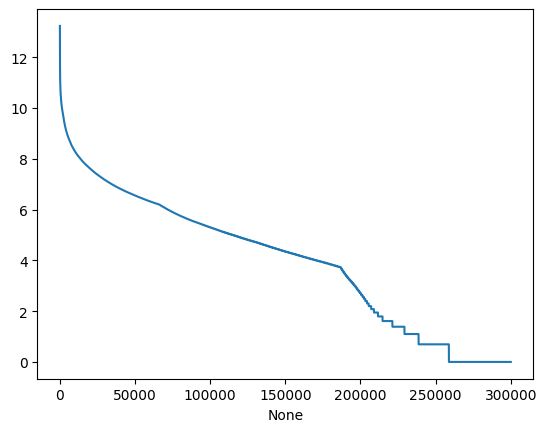

In [6]:
series = (
    pd.Series(df["log_likes"].values).sort_values(ascending=False).reset_index(drop=True)
)
sns.lineplot(x=series.index, y=series.values)

<Axes: xlabel='weekday'>

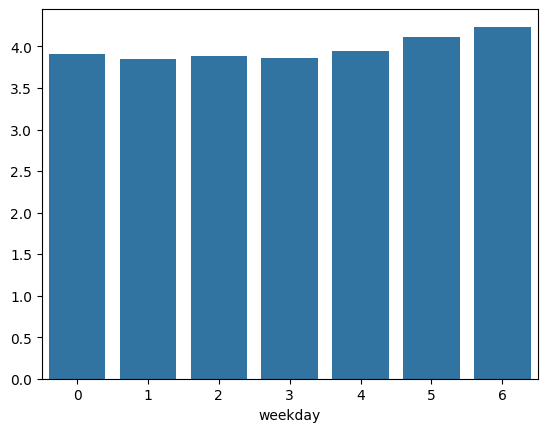

In [9]:
s = df.groupby('weekday')['log_likes'].mean()
sns.barplot(x=s.index, y=s.values)

<Axes: xlabel='post_hour', ylabel='weekday'>

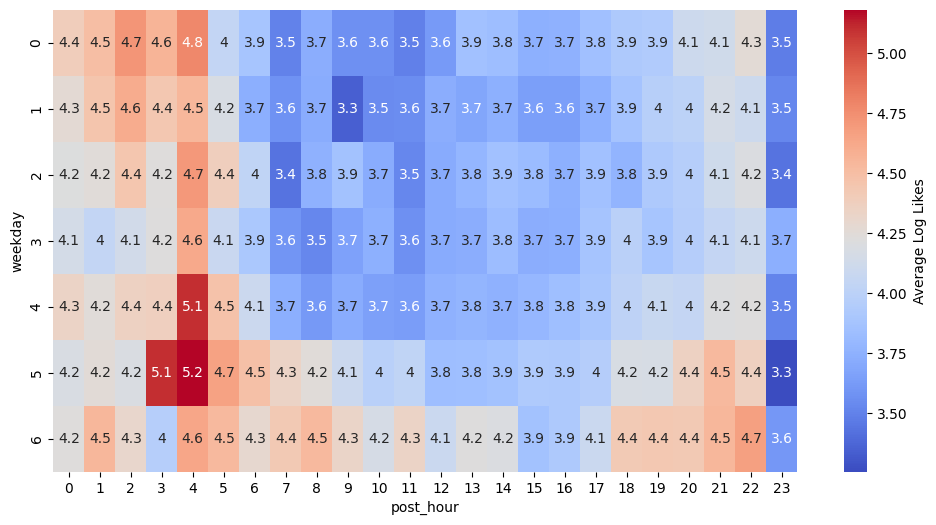

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# create weekday vs post_hour heatmap of average log_likes
heatmap_data = df.groupby(['weekday', 'post_hour'])['log_likes'].mean().unstack()
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', cbar_kws={'label': 'Average Log Likes'})


In [16]:
# print df column names
df.columns

Index(['date', 'likes', 'content', 'username', 'media', 'inferred company',
       'is_viral', 'text_subjectivity', 'word_count', 'char_count',
       'char_density', 'nltk_sentiment_pos', 'nltk_sentiment_neu',
       'nltk_sentiment_neg', 'nltk_sentiment', 'text_sentiment', 'post_hour',
       'weekday', 'post_hour_sin', 'post_hour_cos', 'weekday_sin',
       'weekday_cos', 'media_type', 'has_mention', 'has_emoji', 'company_enc',
       'username_enc', 'num_emojis', 'num_mentions', 'num_hyperlinks',
       'num_hashtags', 'has_hashtags', 'emoji_density', 'is_morning_post',
       'is_afternoon_post', 'is_evening_post', 'is_night_post',
       'is_weekend_post', 'log_likes'],
      dtype='object')

In [38]:
def clean_text(text):
    text = text.lower().strip().replace("\n", " ").replace("\r", " ")

    newtext = ''

    for char in text:
        if char in  'abcdefghijklmnopqrstuvwxyz0123456789 ':
            newtext += char

    newtext = newtext.replace("hyperlink", "").replace("mention", "").replace('  ', ' ')
    return newtext

df['cleaned_text'] = df['content'].apply(clean_text)
df['cleaned_text'].head()

id
1    spend your weekend morning with a ham egg and ...
2             watch rapper freestyle for over an hour 
3    canadian armenian community demands ban on mil...
4    1st in europe to be devastated by covid19 ital...
5    congratulations to pauletha butts of she was p...
Name: cleaned_text, dtype: object

In [39]:
import textblob
newtext_series = df['cleaned_text'].apply(lambda x: textblob.TextBlob(x))

sentiment_series = newtext_series.apply(lambda x: x.sentiment.polarity)
subjectivity_series = newtext_series.apply(lambda x: x.sentiment.subjectivity)

<Axes: xlabel='cleaned_text', ylabel='text_subjectivity'>

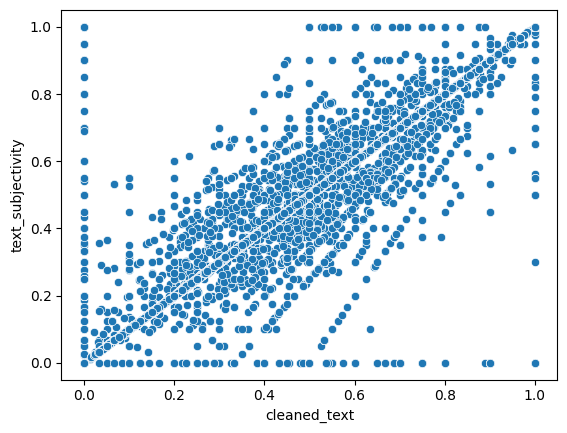

In [41]:
# sns.scatterplot(x=sentiment_series, y=subjectivity_series)
sns.scatterplot(x=subjectivity_series, y=df['text_subjectivity'])

In [43]:
(subjectivity_series ==  df['text_subjectivity']).sum()

np.int64(260813)

<Axes: xlabel='cleaned_text', ylabel='nltk_sentiment'>

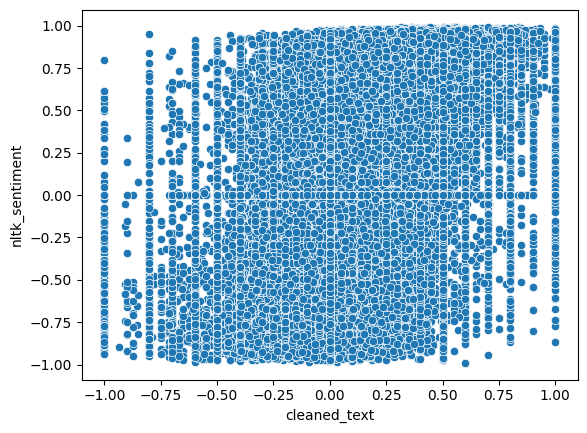

In [42]:
sns.scatterplot(x=sentiment_series, y=df['nltk_sentiment'])

In [78]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=1000,
    min_df=5,
    ngram_range=(1, 2),
    stop_words="english",
)

X_tfidf = tfidf.fit_transform(df["cleaned_text"])  # shape: (300k, 3000)

In [79]:
import numpy as np

feature_names = tfidf.get_feature_names_out()

# Compute mean TF-IDF score for each feature across all tweets
mean_tfidf_scores = X_tfidf.mean(axis=0).A1  # .A1 flattens the matrix row

# Sort by descending score
top_indices = np.argsort(mean_tfidf_scores)[::-1]

# Show top 20 terms by importance
for i in top_indices[:20]:
    print(f"{feature_names[i]}: {mean_tfidf_scores[i]:.5f}")

new: 0.02134
amp: 0.01554
time: 0.01190
just: 0.01167
today: 0.01164
day: 0.01127
learn: 0.01114
like: 0.00963
covid19: 0.00943
watch: 0.00839
know: 0.00817
world: 0.00804
says: 0.00798
help: 0.00796
make: 0.00796
year: 0.00782
people: 0.00741
live: 0.00739
best: 0.00722
president: 0.00716


In [80]:
feature_cols = [
    "nltk_sentiment",
    "text_subjectivity",
    "word_count",
    "char_density",
    "post_hour",
    "weekday",
    "media_type_Photo",
    "media_type_Video",
    "has_mention",
    "has_emoji",
    "num_emojis",
    "has_hashtags",
    "num_hashtags",
    "company_enc",
    "username_enc",
]

X_meta = pd.get_dummies(df, columns=["media_type"], drop_first=True)[feature_cols]

In [81]:
X_meta.values

# change dtype of X_meta to float32
X_meta = X_meta.astype('float32')

In [82]:
from scipy.sparse import csr_matrix, hstack

X_meta_sparse = csr_matrix(X_meta.values)

# Horizontally stack
X_combined = hstack([X_tfidf, X_meta_sparse])

In [86]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, df['log_likes'], test_size=0.2, random_state=42
)

In [87]:
import xgboost as xgb

model = xgb.XGBRegressor(
    n_estimators=200, random_state=42, objective="reg:squarederror"
)
# Fit the model
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [88]:
from sklearn.metrics import root_mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

# If you log-transformed the target, revert it
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred)

rmse = root_mean_squared_error(y_test_orig, y_pred_orig)
print(f"RMSE on test set: {rmse:.2f}")

RMSE on test set: 4443.08


In [90]:
# X_tfidf_train, X_tfidf_test = X_tfidf[:len(X_train)], X_tfidf[len(X_train):]
X_tfidf_train , X_tfidf_test = train_test_split(
    X_tfidf, test_size=0.2, random_state=42
)

model_tfidf = xgb.XGBRegressor(
    n_estimators=200, random_state=42, objective="reg:squarederror"
)

model_tfidf.fit(X_tfidf_train, y_train)
y_pred_tfidf = model_tfidf.predict(X_tfidf_test)
rmse_tfidf = root_mean_squared_error(y_test_orig, np.expm1(y_pred_tfidf))
print(f"RMSE on test set (TF-IDF only): {rmse_tfidf:.2f}")

RMSE on test set (TF-IDF only): 4858.43
